# Unsupervised Analysis — Cardiac Patients

## Load and scale a provided dataset


In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(
    r"C:\Users\Hp\Desktop\binx_mohammadabuhamed\binx_mohammadabuhamed\Cardiac Patients\data\dataprocessed_heart_data.csv"
)
X = df.drop("has_heart_disease", axis=1)
X_numeric = X.select_dtypes(include="number")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

## K-Means Clustering

K-Means Clustering is used to group patients into clusters based on similarities in their numerical health and lifestyle features.

The goal is to explore whether natural patient groups exist in the dataset without using the target variable.

### Elbow Method

The Elbow Method is used to examine different values of `k` and help identify a suitable number of clusters.

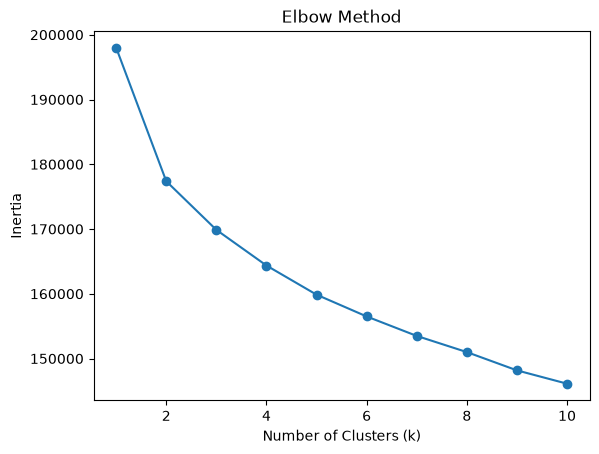

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
iners=[]
for n in range(1,11):
    km=KMeans(n_clusters=n,random_state=42,n_init=10)
    km.fit(X_scaled)
    iners.append(km.inertia_)
    
plt.plot(range(1,11),iners , marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

as we see here its 2 or maybe 3 we will se in **Silhouette Score**

### Silhouette Score

The Silhouette Score is used to evaluate how well the data points fit within their assigned clusters and how separated the clusters are from each other.

In [4]:
from sklearn.metrics import silhouette_score
for n in [2,3]:
    km=KMeans(n_clusters=n,random_state=42,n_init=10)
    label=km.fit_predict(X_scaled)
    score=silhouette_score(X_scaled,label)
    print(f"k={n}, Silhouette Score={score}")

k=2, Silhouette Score=0.09581311069520027
k=3, Silhouette Score=0.06319235709294713


2 is the best

### Train the Final K-Means Model

Based on the Elbow Method and Silhouette Score results, the final K-Means model is trained using two clusters.

In [5]:
final_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)
cluster_labels = final_kmeans.fit_predict(X_scaled)
df["cluster"] = cluster_labels
df["cluster"].value_counts()

cluster
1    4631
0    4369
Name: count, dtype: int64

 ### visualize the cluster with 2 fetures 

 age and daily steps

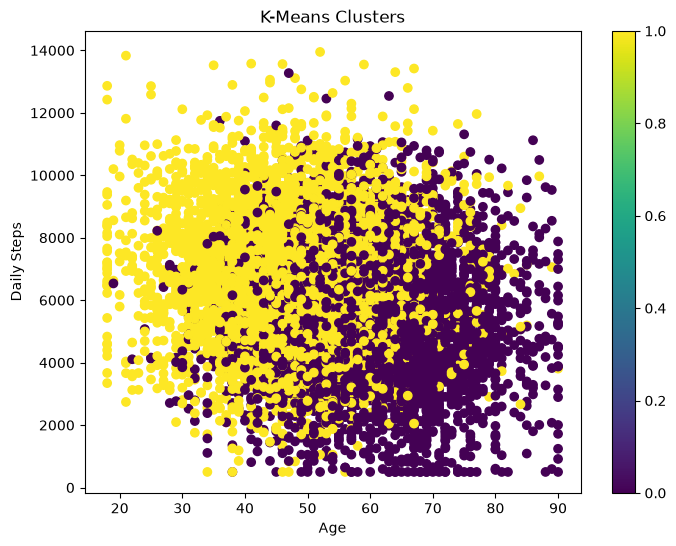

In [11]:
plt.figure(figsize=(8, 6))

scatter=plt.scatter(
    df["age"] ,
    df["daily_steps"],
    c=df["cluster"]
)
plt.colorbar(scatter)
plt.xlabel("Age")
plt.ylabel("Daily Steps")
plt.title("K-Means Clusters")
plt.show()

### Cluster Interpretation

The K-Means model divided the patients into two clusters:

- **Cluster 1:** This cluster appears to contain more older patients, with many patients showing lower to moderate daily activity levels.

- **Cluster 0:** This cluster appears to contain more younger and middle-aged patients, with generally higher daily activity levels.

There is noticeable overlap between the two clusters, meaning that Age and Daily Steps alone do not completely explain the clustering.

The K-Means model was trained using all selected numerical features, while this visualization only shows the clusters using Age and Daily Steps.

## DBSCAN Clustering

DBSCAN is used to identify dense groups of similar patients and detect points located in sparse regions as noise.

Unlike K-Means, DBSCAN does not require specifying the number of clusters in advance.

### Apply DBSCAN

In [18]:
from sklearn.cluster import DBSCAN
db=DBSCAN(eps=2.9,min_samples=6)
dbscan_cluster=db.fit_predict(X_scaled)
df["dbscan_cluster"] = dbscan_cluster
pd.Series(dbscan_cluster).value_counts()



-1     5655
 0     3147
 3      113
 1       43
 9        7
 10       6
 8        6
 6        6
 7        6
 4        5
 2        3
 5        3
Name: count, dtype: int64

### DBSCAN Results

Using `eps=2.9` and `min_samples=6`, DBSCAN identified **11 clusters** and **5,655 noise points**.

A large portion of the dataset was classified as noise, while Cluster 0 was the largest cluster with 3,147 patients.

This indicates that with these DBSCAN parameters, the dataset does not form a small number of clearly dense clusters.

### DBSCAN Cluster Visualization

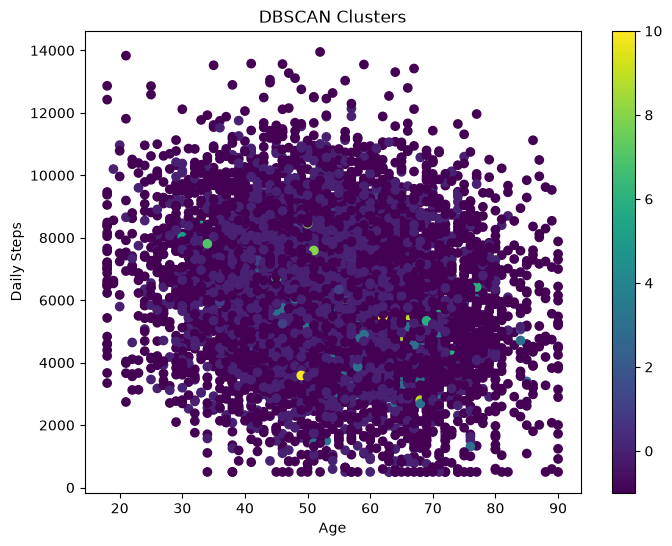

In [19]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    df["age"],
    df["daily_steps"],
    c=df["dbscan_cluster"]
)

plt.colorbar(scatter)

plt.xlabel("Age")
plt.ylabel("Daily Steps")
plt.title("DBSCAN Clusters")

plt.show()

Age and Daily Steps are used only to visualize the DBSCAN results in two dimensions.

The DBSCAN model itself was trained using all scaled numerical features.

### DBSCAN Interpretation

DBSCAN detected several clusters, but a large portion of the dataset was classified as noise.

With the selected parameters, the algorithm identified 11 clusters and classified 5,655 patients as noise.

This suggests that the dataset does not form many clearly separated dense regions under these DBSCAN settings.

The result does not mean that DBSCAN is unsuitable in general; its output is highly sensitive to the selected `eps` and `min_samples` values.

## Hierarchical Clustering

Hierarchical Clustering is used to build a hierarchy of patient groups based on similarity.

A dendrogram is used to visualize how observations are merged into larger clusters.

### Select a Sample for Hierarchical Clustering

In [20]:
X_sapmle=X_scaled[:500]

### Build the Hierarchical Clustering Linkage

Ward linkage is used to merge clusters while trying to keep the increase in within-cluster variance as small as possible.

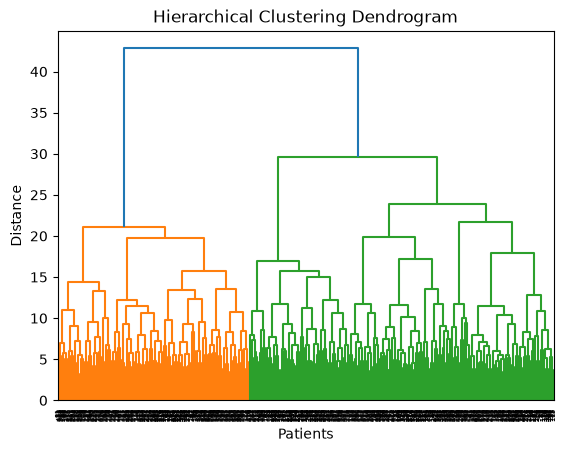

In [21]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt 
z=linkage(X_sapmle,method='ward')
dendrogram(z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Patients")
plt.ylabel("Distance")

plt.show()



The dendrogram shows how individual patients and smaller clusters are gradually merged based on their similarity.

The height of each merge represents the distance between the groups being combined. A higher merge indicates that the groups were more different from each other.

A large gap can be observed between the major merge at approximately 30 and the final merge at approximately 43, suggesting that a natural separation may exist between the two main groups.

### Dendrogram with Cut Height at 33

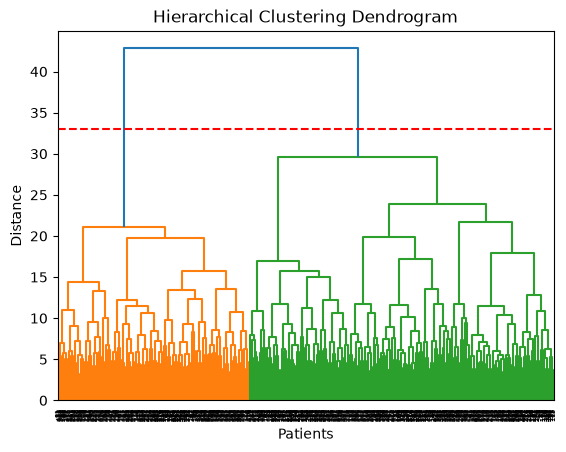

In [22]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt 
z=linkage(X_sapmle,method='ward')
dendrogram(z)
plt.axhline(y=33, color="red", linestyle="--")
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Patients")
plt.ylabel("Distance")

plt.show()




A cut height of 33 was selected because it lies within the large gap between the major merges at approximately 30 and 43.

At this height, the dendrogram is divided into two main branches, resulting in 2 clusters.

This suggests that a two-cluster structure is a reasonable representation of the sampled data.

### Comparison

K-Means and Hierarchical Clustering both suggest that a two-cluster structure may be reasonable for the data.

DBSCAN produced a very different result, identifying many noise points and several small clusters.

##  Principal Component Analysis (PCA)

PCA is used to reduce the dimensionality of the numerical feature space while preserving as much variance as possible.

The goal is to represent the original features using fewer principal components and to examine how much information is retained.

### Fit PCA

In [23]:
from sklearn.decomposition import PCA
pca=PCA()
X_pca=pca.fit(X_scaled)

### Explained Variance Ratio for Each Principal Component

In [24]:
print(pca.explained_variance_ratio_)

[0.16165568 0.0907245  0.07925986 0.07393808 0.06255891 0.05516533
 0.05047894 0.04779952 0.0455491  0.04486229 0.04124949 0.0395539
 0.03763937 0.03554665 0.0352022  0.02458641 0.02402902 0.02235896
 0.01113668 0.00976609 0.00553991 0.0013991 ]


The explained variance ratio shows how much of the total variance is captured by each principal component.

### Calculate the Cumulative Explained Variance

In [25]:
import numpy as np

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print(cumulative_variance)

[0.16165568 0.25238018 0.33164004 0.40557813 0.46813704 0.52330237
 0.57378131 0.62158083 0.66712993 0.71199222 0.75324171 0.79279561
 0.83043498 0.86598163 0.90118383 0.92577024 0.94979926 0.97215822
 0.9832949  0.99306099 0.9986009  1.        ]


The cumulative explained variance is used to determine how many principal components are needed to retain most of the information in the dataset.

### Plot the Cumulative Explained Variance

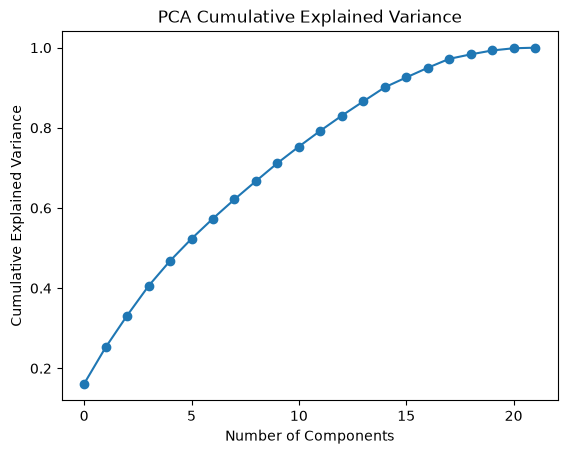

In [26]:
import matplotlib.pyplot as plt
plt.plot(
    cumulative_variance,
    marker="o"
)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.show()


PCA was fitted to the scaled dataset to analyze how much variance is preserved by different numbers of Principal Components.

The cumulative explained variance increases as more components are included.

From the results, approximately 95% of the total variance can be preserved using around 17 Principal Components.

### Reduce the Data to 17 Principal Components

In [27]:
pca_17 = PCA(n_components=17)

X_pca_17 = pca_17.fit_transform(X_scaled)

print(pca_17.explained_variance_ratio_.sum())

0.9497992559150109



17 Principal Components were selected because they preserve approximately **95% of the total variance** in the original data.

This reduces the dataset from **22 dimensions to 17 dimensions** while retaining most of the information contained in the original features.

### Create a Two-Dimensional PCA Representation

### Explained Variance of the First Two Components

In [29]:
pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X_scaled)
print(pca_2.explained_variance_ratio_)
print(pca_2.explained_variance_ratio_.sum())

[0.16165568 0.0907245 ]
0.25238018094986897


### Visualize the Data Using the First Two Principal Components

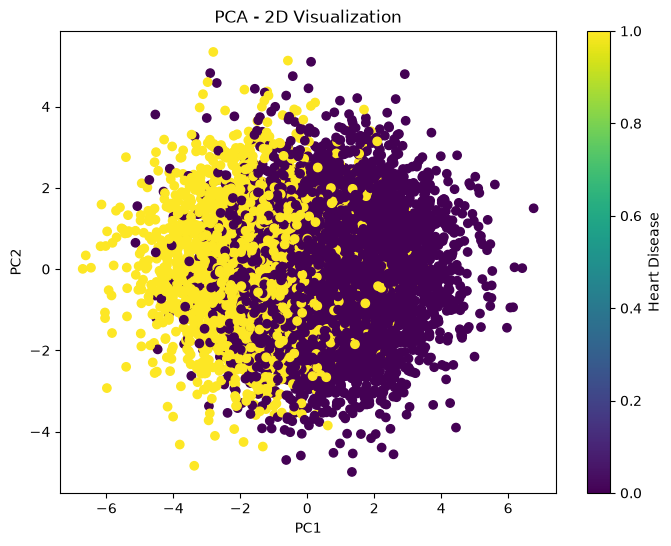

In [30]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca_2[:, 0],
    X_pca_2[:, 1],
    c=df["has_heart_disease"]
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - 2D Visualization")

plt.colorbar(scatter, label="Heart Disease")

plt.show()



The first two Principal Components preserve approximately **25.24% of the total variance**.

The visualization shows some separation between patients with and without heart disease, mainly along PC1. However, there is still considerable overlap between the two groups.

Therefore, the first two components reveal some structure in the data, but they do not fully represent the original dataset.

## t-SNE Visualization

t-SNE is used to visualize high-dimensional patient data in two dimensions while preserving local relationships between similar observations.

Unlike PCA, t-SNE is mainly used for visualization rather than dimensionality reduction for model training.

### Apply t-SNE

In [31]:
from sklearn.manifold import TSNE
tsne=TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)
pred=tsne.fit_transform(X_scaled)
print(pred.shape)


(9000, 2)


### Visualize t-SNE Using K-Means Clusters

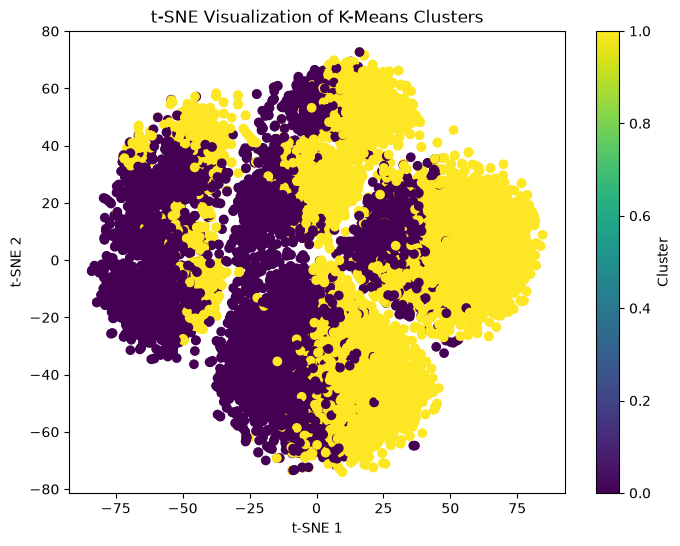

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
scatter=plt.scatter(pred[:,0],pred[:,1],c=df['cluster'])
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Visualization of K-Means Clusters")
plt.colorbar(scatter, label="Cluster")
plt.show()

### t-SNE Visualization Interpretation

The t-SNE visualization reveals local structure in the dataset and shows how the K-Means clusters are distributed in two dimensions.

The two clusters show noticeable separation in several regions, although some overlap between them is still present.

Unlike PCA, the t-SNE axes do not have a direct meaning. The important information is the relative position of the points and which observations appear close to each other.

## Anomaly Detection with Isolation Forest



Isolation Forest is used to detect unusual patient observations that differ from the majority of the dataset.

The goal is to identify potential anomalies based on combinations of numerical health and lifestyle features.

### Apply Isolation Forest to the Dataset

In [34]:
from sklearn.ensemble import IsolationForest
iso=IsolationForest(contamination=0.05,random_state=42)
labels=iso.fit_predict(X_scaled)
labels

array([1, 1, 1, ..., 1, 1, 1], shape=(9000,))

The contamination parameter was set to 0.05, meaning that approximately 5% of the observations are expected to be identified as anomalies.

### Count Normal and Anomalous Points

In [35]:
pd.Series(labels).value_counts()

 1    8550
-1     450
Name: count, dtype: int64

### Isolation Forest Results

Isolation Forest identified:

- **8,550 normal points**
- **450 anomalous points**

The model used `contamination=0.05`, meaning approximately 5% of the dataset was expected to be anomalous.

The flagged points are observations that Isolation Forest considers unusual compared with the overall structure of the dataset. They are not necessarily errors or incorrect records.